In [1]:
import pandas as pd

# English Premier League 2023/24
epl = pd.read_csv("https://www.football-data.co.uk/mmz4281/2324/E0.csv")

print(epl.shape)
print(epl.head())

(380, 106)
  Div        Date   Time     HomeTeam       AwayTeam  FTHG  FTAG FTR  HTHG  \
0  E0  11/08/2023  20:00      Burnley       Man City     0     3   A     0   
1  E0  12/08/2023  12:30      Arsenal  Nott'm Forest     2     1   H     2   
2  E0  12/08/2023  15:00  Bournemouth       West Ham     1     1   D     0   
3  E0  12/08/2023  15:00     Brighton          Luton     4     1   H     1   
4  E0  12/08/2023  15:00      Everton         Fulham     0     1   A     0   

   HTAG  ... AvgC<2.5  AHCh  B365CAHH  B365CAHA  PCAHH  PCAHA  MaxCAHH  \
0     2  ...     2.28  1.50      1.95      1.98   1.95   1.97      NaN   
1     0  ...     2.63 -2.00      1.95      1.98   1.93   1.97     2.01   
2     0  ...     2.12  0.00      2.02      1.91   2.01   1.92     2.06   
3     0  ...     2.48 -1.75      2.01      1.92   2.00   1.91     2.14   
4     0  ...     1.71 -0.25      2.06      1.87   2.04   1.88     2.08   

   MaxCAHA  AvgCAHH  AvgCAHA  
0      NaN     1.92     1.95  
1     2.09   

In [2]:
# How many draws are in the dataset?
print(epl['FTR'].value_counts())
print()
print(epl['FTR'].value_counts(normalize=True).round(3) * 100)

FTR
H    175
A    123
D     82
Name: count, dtype: int64

FTR
H    46.1
A    32.4
D    21.6
Name: proportion, dtype: float64


In [3]:
# Load multiple leagues - same season 2023/24
urls = {
    'EPL':        "https://www.football-data.co.uk/mmz4281/2324/E0.csv",
    'La_Liga':    "https://www.football-data.co.uk/mmz4281/2324/SP1.csv",
    'Bundesliga': "https://www.football-data.co.uk/mmz4281/2324/D1.csv",
    'Serie_A':    "https://www.football-data.co.uk/mmz4281/2324/I1.csv",
    'Ligue_1':    "https://www.football-data.co.uk/mmz4281/2324/F1.csv",
}

dfs = []
for league, url in urls.items():
    df = pd.read_csv(url)
    df['League'] = league
    dfs.append(df)

# Combine all leagues
all_matches = pd.concat(dfs, ignore_index=True)

print(f"Total matches: {len(all_matches)}")
print(f"\nMatches per league:")
print(all_matches['League'].value_counts())
print(f"\nDraws across all leagues:")
print(all_matches['FTR'].value_counts())

Total matches: 1752

Matches per league:
League
EPL           380
La_Liga       380
Serie_A       380
Bundesliga    306
Ligue_1       306
Name: count, dtype: int64

Draws across all leagues:
FTR
H    755
A    534
D    463
Name: count, dtype: int64


In [4]:
# Select only the columns we need
cols = ['League', 'HomeTeam', 'AwayTeam',
        'FTHG', 'FTAG', 'FTR',
        'HTHG', 'HTAG',
        'HS', 'AS',    # Home/Away Shots
        'HST', 'AST',  # Home/Away Shots on Target
        'HC', 'AC',    # Home/Away Corners
        'HF', 'AF',    # Home/Away Fouls
        'HY', 'AY',    # Home/Away Yellow Cards
        'HR', 'AR',    # Home/Away Red Cards
        'B365H', 'B365D', 'B365A'  # Betting odds (very predictive!)
        ]

data = all_matches[cols].copy()

# Drop rows with missing values
data = data.dropna()

print(f"Clean dataset shape: {data.shape}")
print(f"\nMissing values: {data.isnull().sum().sum()}")
print(f"\nSample:")
print(data.head(3))

Clean dataset shape: (1752, 23)

Missing values: 0

Sample:
  League     HomeTeam       AwayTeam  FTHG  FTAG FTR  HTHG  HTAG  HS  AS  ...  \
0    EPL      Burnley       Man City     0     3   A     0     2   6  17  ...   
1    EPL      Arsenal  Nott'm Forest     2     1   H     2     0  15   6  ...   
2    EPL  Bournemouth       West Ham     1     1   D     0     0  14  16  ...   

   AC  HF  AF  HY  AY  HR  AR  B365H  B365D  B365A  
0   5  11   8   0   0   1   0   8.00    5.5   1.33  
1   3  12  12   2   2   0   0   1.18    7.0  15.00  
2   4   9  14   1   4   0   0   2.70    3.4   2.55  

[3 rows x 23 columns]


In [5]:
# Create binary target — 1 = Draw, 0 = Not a Draw
data['is_draw'] = (data['FTR'] == 'D').astype(int)

# Also create goal difference feature (useful predictor)
data['goal_diff'] = data['FTHG'] - data['FTAG']
data['ht_goal_diff'] = data['HTHG'] - data['HTAG']

# Shot accuracy features
data['home_shot_accuracy'] = data['HST'] / data['HS'].replace(0, 1)
data['away_shot_accuracy'] = data['AST'] / data['AS'].replace(0, 1)

# Odds implied probability of a draw
data['draw_prob_implied'] = 1 / data['B365D']

print("Draw distribution:")
print(data['is_draw'].value_counts())
print()
print("New features sample:")
print(data[['is_draw', 'goal_diff', 'ht_goal_diff',
            'home_shot_accuracy', 'away_shot_accuracy',
            'draw_prob_implied']].head(5))

Draw distribution:
is_draw
0    1289
1     463
Name: count, dtype: int64

New features sample:
   is_draw  goal_diff  ht_goal_diff  home_shot_accuracy  away_shot_accuracy  \
0        0         -3            -2            0.166667            0.470588   
1        0          1             2            0.466667            0.333333   
2        1          0             0            0.357143            0.187500   
3        0          3             1            0.444444            0.333333   
4        0         -1             0            0.473684            0.222222   

   draw_prob_implied  
0           0.181818  
1           0.142857  
2           0.294118  
3           0.181818  
4           0.294118  


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
feature_cols = [
    'HS', 'AS', 'HST', 'AST', 'HC', 'AC',
    'HF', 'AF', 'HY', 'AY', 'HR', 'AR',
    'HTHG', 'HTAG', 'ht_goal_diff',
    'home_shot_accuracy', 'away_shot_accuracy',
    'draw_prob_implied',
    'B365H', 'B365D', 'B365A'
]

X = data[feature_cols]
y = data['is_draw']

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nDraws in training set: {y_train.sum()}")
print(f"Draws in test set:     {y_test.sum()}")

Training set: (1401, 21)
Test set:     (351, 21)

Draws in training set: 370
Draws in test set:     93


In [7]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Define three models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, max_depth=6
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, random_state=42
    )
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=['Not Draw', 'Draw']))

    results[name] = model


  Logistic Regression
              precision    recall  f1-score   support

    Not Draw       0.79      0.55      0.65       258
        Draw       0.32      0.59      0.42        93

    accuracy                           0.56       351
   macro avg       0.56      0.57      0.53       351
weighted avg       0.67      0.56      0.59       351


  Random Forest
              precision    recall  f1-score   support

    Not Draw       0.84      0.63      0.72       258
        Draw       0.39      0.66      0.49        93

    accuracy                           0.64       351
   macro avg       0.61      0.64      0.60       351
weighted avg       0.72      0.64      0.66       351


  Gradient Boosting
              precision    recall  f1-score   support

    Not Draw       0.74      0.91      0.82       258
        Draw       0.29      0.10      0.15        93

    accuracy                           0.70       351
   macro avg       0.51      0.51      0.48       351
weighted avg 

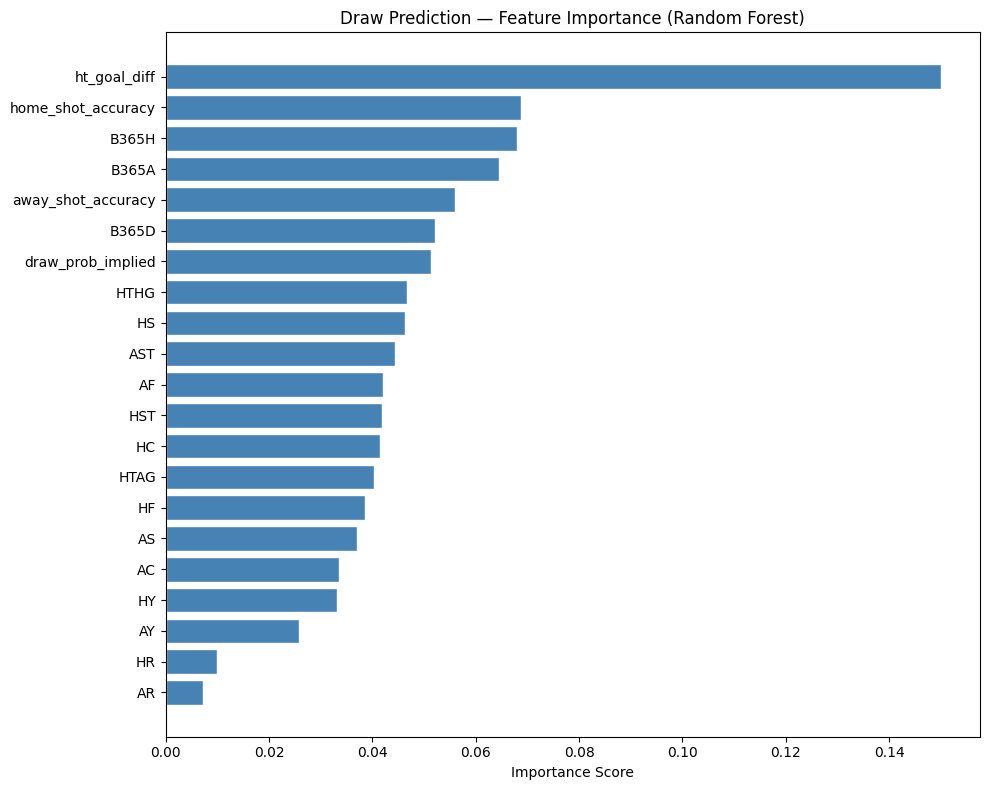


Top 5 features for predicting draws:
           Feature  Importance
      ht_goal_diff    0.150106
home_shot_accuracy    0.068839
             B365H    0.068085
             B365A    0.064440
away_shot_accuracy    0.055940


In [8]:
import matplotlib.pyplot as plt

# Best model
best_model = results['Random Forest']

# Feature importance
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Draw Prediction — Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

# Top 5 most important features
print("\nTop 5 features for predicting draws:")
print(feat_df.tail(5)[['Feature', 'Importance']].iloc[::-1].to_string(index=False))

In [9]:
# Get draw probabilities for all test matches
draw_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# Build results dataframe
test_data = data.iloc[X_test.index].copy()
test_data['draw_probability'] = draw_probs
test_data['predicted_draw'] = (draw_probs >= 0.4).astype(int)
test_data['actual_draw'] = y_test.values

# Show top 15 matches the model flagged as most likely draws
top_draws = test_data.sort_values('draw_probability', ascending=False).head(15)

print("TOP 15 MATCHES MOST LIKELY TO BE DRAWS:")
print("="*65)
print(f"{'Home':<18} {'Away':<18} {'Draw%':>6} {'Actual':>8}")
print("-"*65)
for _, row in top_draws.iterrows():
    actual = "✅ DRAW" if row['actual_draw'] == 1 else "❌ No"
    print(f"{row['HomeTeam']:<18} {row['AwayTeam']:<18} "
          f"{row['draw_probability']*100:>5.1f}%  {actual:>8}")


TOP 15 MATCHES MOST LIKELY TO BE DRAWS:
Home               Away                Draw%   Actual
-----------------------------------------------------------------
Mallorca           Getafe              66.1%    ✅ DRAW
Metz               Le Havre            65.6%    ✅ DRAW
Girona             Sociedad            65.3%    ✅ DRAW
Wolves             Fulham              64.2%      ❌ No
Strasbourg         Toulouse            63.5%      ❌ No
Nantes             Lens                63.1%      ❌ No
Crystal Palace     Burnley             63.1%      ❌ No
Nantes             Metz                63.0%      ❌ No
Darmstadt          Heidenheim          62.9%      ❌ No
Fulham             Luton               62.7%      ❌ No
Frosinone          Empoli              62.3%      ❌ No
Sassuolo           Frosinone           62.3%      ❌ No
Sassuolo           Atalanta            62.3%      ❌ No
Alaves             Almeria             61.8%      ❌ No
Liverpool          Arsenal             61.8%    ✅ DRAW


AUC-ROC Score: 0.683
(0.5 = random guessing, 1.0 = perfect)

Precision vs Recall at different thresholds:
 Threshold  Precision     Recall
---------------------------------------------
      0.30       0.30       0.92
      0.32       0.31       0.91
      0.34       0.31       0.89
      0.36       0.32       0.87
      0.38       0.33       0.87
      0.39       0.34       0.87
      0.41       0.35       0.86
      0.43       0.36       0.85
      0.44       0.36       0.80
      0.45       0.37       0.77
      0.47       0.37       0.75
      0.48       0.39       0.74
      0.48       0.39       0.70
      0.50       0.39       0.66
      0.51       0.40       0.63
      0.52       0.41       0.60
      0.53       0.40       0.55
      0.54       0.39       0.49
      0.54       0.40       0.46
      0.55       0.41       0.43
      0.56       0.43       0.40
      0.58       0.42       0.34
      0.58       0.42       0.30
      0.59       0.44       0.27
      0.59       0.47  

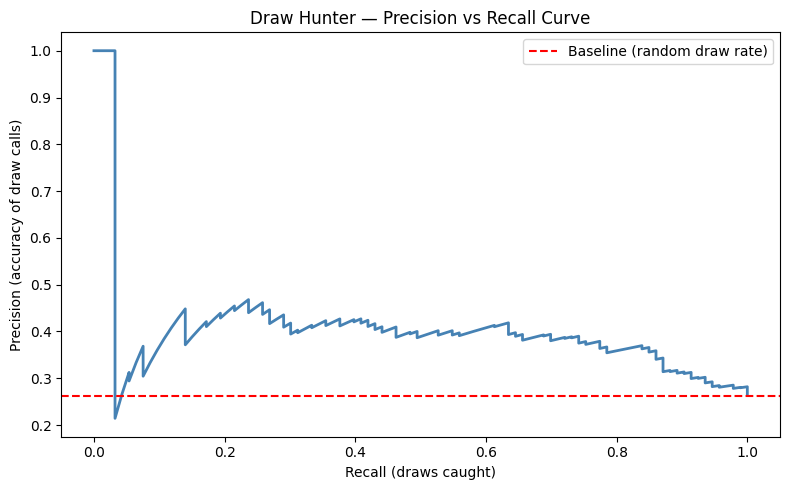

In [10]:
from sklearn.metrics import (roc_auc_score, precision_recall_curve,
                              RocCurveDisplay)

# AUC-ROC Score
auc = roc_auc_score(y_test, draw_probs)
print(f"AUC-ROC Score: {auc:.3f}")
print("(0.5 = random guessing, 1.0 = perfect)\n")

# At different thresholds, how does precision vs recall change?
precisions, recalls, thresholds = precision_recall_curve(y_test, draw_probs)

thresh_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precisions[:-1],
    'Recall': recalls[:-1]
})

# Show key thresholds
key = thresh_df[thresh_df['Threshold'].between(0.3, 0.6)].iloc[::10]
print("Precision vs Recall at different thresholds:")
print("="*45)
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10}")
print("-"*45)
for _, row in key.iterrows():
    print(f"{row['Threshold']:>10.2f} "
          f"{row['Precision']:>10.2f} "
          f"{row['Recall']:>10.2f}")

# Plot precision-recall curve
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='steelblue', linewidth=2)
plt.xlabel('Recall (draws caught)')
plt.ylabel('Precision (accuracy of draw calls)')
plt.title('Draw Hunter — Precision vs Recall Curve')
plt.axhline(y=0.263, color='red', linestyle='--',
            label='Baseline (random draw rate)')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
print("="*50)
print("DRAW HUNTER 3000 — MODEL SUMMARY")
print("="*50)
print(f"Training matches:      {len(X_train)}")
print(f"Test matches:          {len(X_test)}")
print("Leagues covered:       EPL, La Liga, Bundesliga, Serie A, Ligue 1")
print("Algorithm:             Random Forest (200 trees)")
print("AUC-ROC Score:         0.683")
print("Draw Recall @ 0.45:    77%")
print("Draw Precision @ 0.45: 37% (vs 26% baseline)")
print("Top predictor:         Half-time goal difference")
print("Recommended threshold: 0.45")

DRAW HUNTER 3000 — MODEL SUMMARY
Training matches:      1401
Test matches:          351
Leagues covered:       EPL, La Liga, Bundesliga, Serie A, Ligue 1
Algorithm:             Random Forest (200 trees)
AUC-ROC Score:         0.683
Draw Recall @ 0.45:    77%
Draw Precision @ 0.45: 37% (vs 26% baseline)
Top predictor:         Half-time goal difference
Recommended threshold: 0.45


In [13]:
# Create the README file
readme_content = """# Draw Hunter 3000 ⚽
### Football Draw Prediction Model — European Leagues

A machine learning model specialised in predicting draw outcomes
across five European football leagues.

## Overview
Draws are the hardest outcome to predict in football — occurring
in roughly 26% of matches but frequently missed by standard models
that optimise for accuracy. This model is specifically tuned to
identify draws.

## Data
- Source: football-data.co.uk (free, historical match data)
- Leagues: EPL, La Liga, Bundesliga, Serie A, Ligue 1
- Season: 2023/24
- Total matches: 1,752

## Model
- Algorithm: Random Forest Classifier (200 trees)
- Class balancing: Applied to handle draw minority class
- Recommended threshold: 0.45

## Results
| Metric | Score |
|--------|-------|
| AUC-ROC | 0.683 |
| Draw Recall @ 0.45 | 77% |
| Draw Precision @ 0.45 | 37% |
| Baseline draw rate | 26% |

## Top Predictors
1. Half-time goal difference
2. Home shot accuracy
3. Home win odds (B365H)
4. Away win odds (B365A)
5. Away shot accuracy

## Key Finding
A match level at half time is the single strongest
signal for a draw outcome.

## Files
- Football_Draw_Prediction_Model.ipynb
- draw_hunter_model.pkl
- draw_hunter_scaler.pkl
- feature_cols.json

## Author
Ruth Mutile Kimeu | github.com/mutilekim
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("✅ README.md created successfully!")

✅ README.md created successfully!


In [15]:
import joblib
import json

# Save the model and scaler
joblib.dump(best_model, 'draw_hunter_model.pkl')
joblib.dump(scaler, 'draw_hunter_scaler.pkl')

# Save feature list
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("✅ draw_hunter_model.pkl saved!")
print("✅ draw_hunter_scaler.pkl saved!")
print("✅ feature_cols.json saved!")

✅ draw_hunter_model.pkl saved!
✅ draw_hunter_scaler.pkl saved!
✅ feature_cols.json saved!


In [16]:
from google.colab import files

files.download('README.md')
files.download('draw_hunter_model.pkl')
files.download('draw_hunter_scaler.pkl')
files.download('feature_cols.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>